In [1]:
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
from torch.utils.data.dataset import TensorDataset
from torch.utils.data import DataLoader

Text(0, 0.5, 'Y')

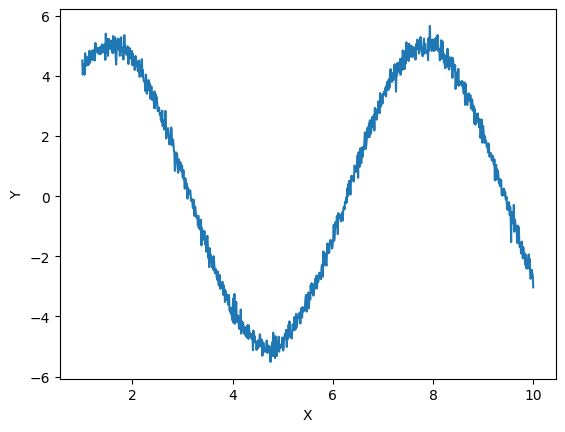

In [2]:
## Data generation

N_data = 1000
data_x = np.linspace(1.0, 10.0, N_data)[:, np.newaxis]
data_y = 5*np.sin(data_x) + 0.2*np.random.randn(N_data,1)

plt.plot( data_x.flatten(), data_y.flatten()  )
plt.xlabel('X')
plt.ylabel('Y')

In [3]:
## Data pre-processing

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data_x, data_y, test_size=0.2, random_state=42)

x_train = torch.FloatTensor(X_train)
x_valid = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(Y_train)
y_valid = torch.FloatTensor(Y_test)

train_ds = TensorDataset(x_train,y_train)
valid_ds = TensorDataset(x_valid,y_valid)

# Dataloader creation; used to batch together items for training, it returns multiple (x,y) every time you loop over it
dataloader = DataLoader(train_ds,batch_size=10,shuffle=True)

In [13]:
## Architecture

class DeepNormal(torch.nn.Module):

    def __init__(self, n_inputs, n_hidden):
        super().__init__()

        # Shared parameters
        self.shared_layer = torch.nn.Sequential(
            torch.nn.Linear(n_inputs, n_hidden),
            torch.nn.ReLU(),
        )

        # Mean parameters
        self.mean_layer = torch.nn.Sequential(
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, 1),
        )

        # Standard deviation parameters
        self.std_layer = torch.nn.Sequential(
            torch.nn.Linear(n_hidden, n_hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(n_hidden, 1),
            torch.nn.Softplus(),
        )

    def forward(self, x):
        # Shared embedding
        shared = self.shared_layer(x)

        # Parametrization of the mean
        mu = self.mean_layer(shared)

        # Parametrization of the standard deviation
        sigma = self.std_layer(shared)

        # This is the function that will define a ditribution
        # We now have two different output and we can use them to build a gaussian probability where mu and sigma
        # Boths depends on the input variables
        return torch.distributions.Normal(mu, sigma)

In [14]:
## Training

# The loss function we want to minimize is the log-likelihood itself!
def compute_loss(normal_dist, y):
    neg_log_likelihood = -normal_dist.log_prob(y)
    return torch.mean(neg_log_likelihood)

model = DeepNormal(1,60)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    for x,y in dataloader:
        optimizer.zero_grad()
        output = model(x)
        loss = compute_loss(output,y)
        loss.backward()
        optimizer.step()

Text(0, 0.5, 'Y')

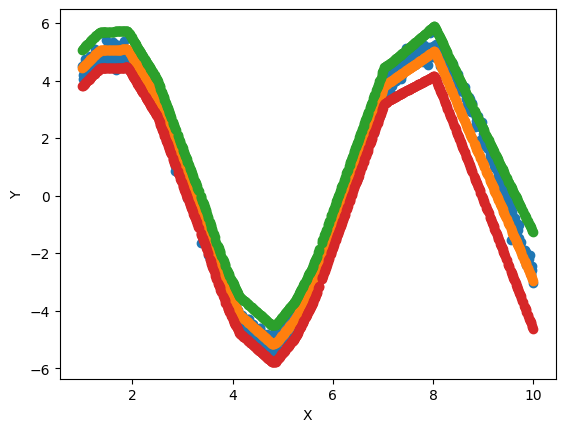

In [15]:
## Evaluation

model.eval()
normal_dist = model(x_train)
mean = normal_dist.mean
std = normal_dist.stddev

plt.scatter(x_train,y_train)
plt.scatter(x_train,mean.detach().numpy())
plt.scatter(x_train,mean.detach().numpy()+2*std.detach().numpy())
plt.scatter(x_train,mean.detach().numpy()-2*std.detach().numpy())
plt.xlabel('X')
plt.ylabel('Y')